In [1]:

import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate

from autotsc import utils

In [ ]:
df = (
    pl.scan_parquet("s3://tsc-glue/performance/*.parquet")
    #.filter(pl.col("model") != "mixed-v2")
    #.filter(pl.col("model") != "mixed-v3")
    #.filter(pl.col("model") != "mixed-v4")  
    #.filter(pl.col("model") != "mixed")
    .filter(pl.col("model") != "hivecotev2")
    .filter(pl.col("model") != "stacker-v4-r3")
    #.filter(pl.col("model") != "stacker-v4-r1")


).collect(engine="streaming")
df

dataset,model,run,resampled,test_accuracy
str,str,i64,bool,f64
"""MiddlePhalanxTW""","""catch22""",400,false,0.519481
"""SemgHandMovementCh2""","""mr-hydra""",300,false,0.771111
"""MixedShapesSmallTrain""","""catch22""",400,false,0.861856
"""FaceFour""","""mr-hydra""",100,false,0.943182
"""MoteStrain""","""catch22""",300,false,0.876997
…,…,…,…,…
"""Worms""","""catch22""",200,false,0.753247
"""FordB""","""mr-hydra""",200,false,0.835802
"""ScreenType""","""rstsf""",100,false,0.541333


In [15]:
df.group_by("model").agg(pl.len()).sort("len", descending=True)

model,len
str,u32
"""rstsf""",640
"""catch22""",640
"""mr-hydra""",640
"""quant""",640
"""rdst""",640
"""u-rstsf""",266


In [16]:
from aeon.visualisation import plot_critical_difference

In [17]:
v = df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).drop_nulls()
methods = df["model"].unique().to_list()
v

dataset,catch22,mr-hydra,quant,rdst,u-rstsf,rstsf
str,f64,f64,f64,f64,f64,f64
"""MiddlePhalanxTW""",0.54026,0.52987,0.580519,0.52987,0.584416,0.574026
"""SemgHandMovementCh2""",0.797778,0.757333,0.834222,0.699111,0.831111,0.855556
"""MixedShapesSmallTrain""",0.861608,0.966763,0.928082,0.966928,0.905979,0.908948
"""FaceFour""",0.609091,0.947727,0.975,0.988636,0.943182,0.995455
"""MoteStrain""",0.871406,0.94377,0.946645,0.928275,0.938498,0.948083
…,…,…,…,…,…,…
"""ChlorineConcentration""",0.590469,0.790573,0.750312,0.761823,0.747483,0.751146
"""RefrigerationDevices""",0.507733,0.526933,0.581867,0.5568,0.581333,0.5904
"""Wafer""",0.998118,0.999676,1.0,1.0,0.998215,0.99974


(<Figure size 600x250 with 1 Axes>, <Axes: >)

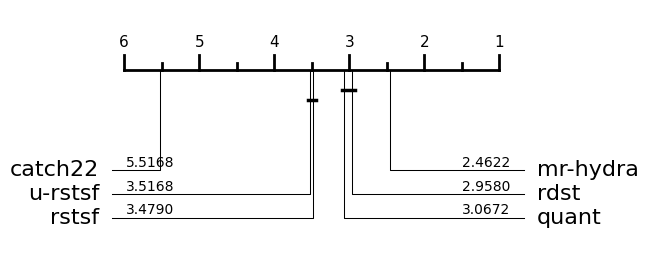

In [18]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [19]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [8]:
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,catch22,mr-hydra,stacker-v4-r1,quant,rdst,u-rstsf,rstsf,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DodgerLoopGame""",0.708661,0.858268,0.858268,0.867717,0.848819,0.870079,0.870866,17,127,2,288
"""DodgerLoopWeekend""",0.968254,0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,18,126,2,288
"""TwoLeadECG""",0.797717,0.998244,0.997366,0.996488,0.997717,0.964296,0.990518,23,1139,2,82
"""Symbols""",0.963216,0.981307,0.978894,0.980503,0.980302,0.979899,0.970854,25,995,6,398
"""SonyAIBORobotSurface2""",0.920672,0.941658,0.93809,0.848059,0.894229,0.903463,0.882057,27,953,2,65
…,…,…,…,…,…,…,…,…,…,…,…
"""UWaveGestureLibraryY""",0.703853,0.808208,0.812116,0.770966,0.764098,0.765215,0.751982,896,3582,8,315
"""HandOutlines""",0.862162,0.94973,0.951351,0.922703,0.948649,0.915541,0.912973,1000,370,2,2709
"""StarLightCurves""",0.96831,0.981666,0.982637,0.979845,0.98237,0.980391,0.979699,1000,8236,3,1024


25


(<Figure size 600x260 with 1 Axes>, <Axes: >)

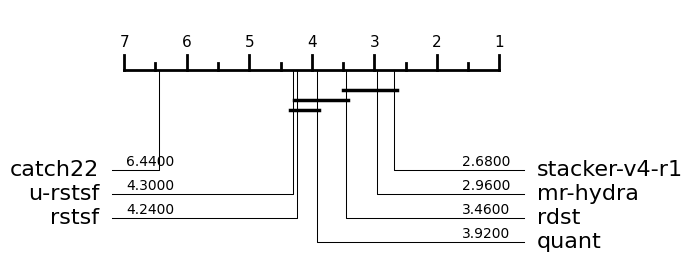

In [9]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

17


(<Figure size 600x260 with 1 Axes>, <Axes: >)

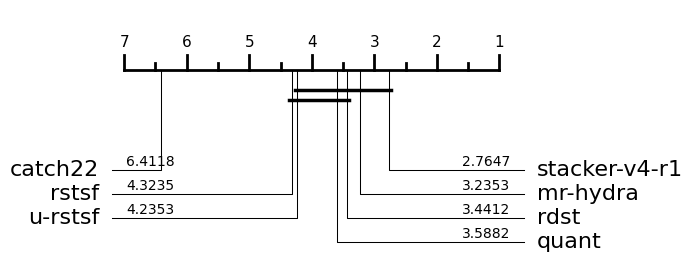

In [10]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

8


(<Figure size 600x260 with 1 Axes>, <Axes: >)

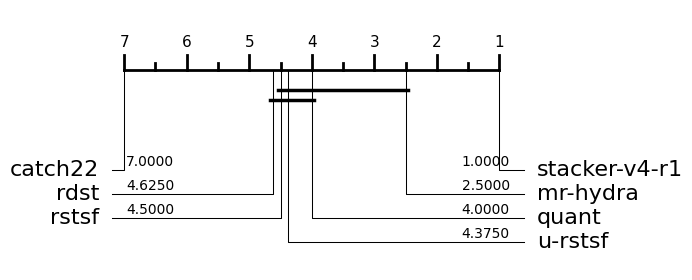

In [11]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [12]:
s_large

dataset,catch22,mr-hydra,stacker-v4-r1,quant,rdst,u-rstsf,rstsf,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""MiddlePhalanxOutlineCorrect""",0.766323,0.851546,0.860825,0.848797,0.839175,0.844502,0.845361,600,291,2,80
"""ProximalPhalanxOutlineCorrect""",0.837113,0.919588,0.924399,0.907904,0.886598,0.904926,0.913402,600,291,2,80
"""UWaveGestureLibraryX""",0.761865,0.871245,0.872976,0.844556,0.855388,0.840452,0.825349,896,3582,8,315
"""UWaveGestureLibraryY""",0.703853,0.808208,0.812116,0.770966,0.764098,0.765215,0.751982,896,3582,8,315
"""HandOutlines""",0.862162,0.94973,0.951351,0.922703,0.948649,0.915541,0.912973,1000,370,2,2709
"""StarLightCurves""",0.96831,0.981666,0.982637,0.979845,0.98237,0.980391,0.979699,1000,8236,3,1024
"""PhalangesOutlinesCorrect""",0.78042,0.846154,0.850816,0.841492,0.807925,0.841492,0.844988,1800,858,2,80
"""FordA""",0.914394,0.951364,0.986364,0.971515,0.949091,0.975,0.975152,3601,1320,2,500


In [13]:
import ray
ray.shutdown()